# Background

To build a radar map of the moon, we want to process all of the available data (many "Looks" across many days) into intensity values for each point on the moon's surface.

In essence, we combine samples over a duration of a few minutes into a coherent doppler/delay (DD) Look, which we then map to intensity values the moon's surface. We can repeat this process for each Look, and then incoherently combine the Looks by taking the average of the intensity values at each point, for instance.

There are several relevant frames:
* The RX frame (at Stockert)
* The TX frame (at Dwingeloo)
* The Moon frame, which is where the bounces occur.
 - The Moon is significantly not spherical, which requires raycasting to model accurately!

Bouncing a radar signal from the transmitter to the moon to the receiver causes a Doppler effect, which is usually though of as a change in frequency or pitch. This effect can be interpreted in the frequency domain, or the time domain:
* Frequency Domain: at each tx or rx sample time, there is an instantaneous frequency shift caused by the relative velocity of the two bodies during the signal round trip -- this is the classical Doppler shift.
* Time Domain: at each rx sample time, there is a corrected tx sample timing caused by the signal propagation delay. The effect of shifting the signal timing is to cause an apparent frequency shift!

Both of these effects cause a frequency shift, but the time domain interpretation is more accurate, since it also corrects for the timing of various signal events (start, stop, internal structure). We will use the term Doppler shift or Doppler effect to generically refer the overall phenomenon, which can be modeled using either of these interpretations.

(AM I RIGHT ABOUT THIS OR COMPLETELY BONKERS?)

(IN IMPLEMENTATION, IS TIME DOMAIN INTERPOLATION ACTUALLY BETTER, COMPARED WITH FREQUENCY DOMAIN SHIFTING?)

(DO WE HAVE A HIGH-PRECISION DESCRIPTION OF THE TX SIGNAL THAT WE COULD SUPER-SAMPLE?)

Because of light time delays, and the changing relative motion of the Earth and Moon, and oblateness of the Moon, we need to use relativistic raycasting to model the Doppler and delay .

The most tricky part is assembling the Looks. We have several options to convert the samples into moon surface values.
1. Full relativistic raycast: for each rx sample of the Look, cast a BACK ray to each point on the moon and then a BACK ray to the TX. Correct the TX sample timing accordingly and correlate the corrected signal over the duration of the Look with the RX signal to get the moon surface intensity at that point. This takes into account the full complexity of the light propagation and relative motion of the 3 points of interest (tx, bounce, rx).
    1. NOTE: this is likely very computationally intensive!
2. Sub-radar point SRP) relativistic raycast. The change in relative motion (and thus doppler) due to the delay depth of the moon is probably pretty small. So we can instead just use the SRP (rather than each point on the moon) to estimate the Doppler correction.
    1. Then correct the {RX or TX TBD} samples:
        1. Time domain: Resample the TX or RX signal to the adjusted timestamps
        2. Frequency domain: Shift the {RX, TX} signal frequency by the time-varying doppler
    2. Correlate the corrected signal with the (original) {OTHER} signal across a range of doppler shifts (due to the motion of the limbs of the moon): this yields a single "look" at the rx signal start time
    3. Then raycast for points on the lunar surface to predict the dopplers/delays of at the "look" time for each point, and convert the "look" doppler/delay intensity values into moon coordinates.
3. Sub-radar, linear rate of Doppler. Like 2, but instead of computing the corrected sample timing or instantaneous frequency shift for each sample, just compute them for the {RX, TX} start and end times and assume a linear rate in between. Use this simpler correction for (2.A), then do (2.B) and (2.C) as in (2).
    1. NOTE: this is what we've been doing (frequency domain only)

Residual issues:
* I suspect, due to my lack of understanding of what it means for two separate locations (Dwingeloo and Stockert) to both use UTC and claim simultaneous events in those two locations, that there may be a residual time offset correction between the two sites. Due to the geometry of the sitation, this time offset is probably near-constant during a Look, but may vary between looks.
* We've been seeing hints of this the whole time, in odd offsets in delay or cross-correlation peaks.
* We may be able to identify the time offset correction by searching for the offset that maximizes the tx-to-rx correlation.


## Basic principle of Planetary Radar:
Transmit short pulses at a given frequency for distance/c time
 * pulse duration should be ... pretty short (have to sum up many pulses to deal with noise)
 * pulse interval should be longer than the delay dispersion
 * or use coded long pulse waveform (pseudo-random)
 * Receive the echos, compute the response for each cell in a doppler delay grid (doppler varies across the limbs, delay varies with distance)

## Relevant papers
 * [Radar Echoes From the Moon](https://web.archive.org/web/20081029000712/http://www.eagle.ca/~harry/ba/eme/index.htm) -- historical
 * [Planetary Radar - State-of-the-Art Review](https://www.mdpi.com/2072-4292/15/23/5605) -- 2023 overview
 * [Planetary Radar Astronomy](https://nap.nationalacademies.org/read/21729/chapter/8) -- 2015 overview
 * [Planetary Radar](https://echo.jpl.nasa.gov/asteroids/ostro_1998_encyc_ss.pdf) -- 1998 overview
 * [Planetary Delay-Doppler Radar and the Long-Code Method](https://echo.jpl.nasa.gov/asteroids/harmon.2002.long.code.pdf) -- long-code method (recommends intercode -- coherent code sequence) for underspread Moon
 * [Earth-Based Radar Observations of Venus -- PDS Archive Description](https://pds-geosciences.wustl.edu/venus/arcb_nrao-v-rtls_gbt-3-delaydoppler-v1/vrm_90xx/document/venus_radar.pdf) -- Arecibo Venus data description

In [1]:
# To fetch the camras data, use something like:
#! wget -r --no-clobber --no-parent -R index.html?* https://data.camras.nl/thomas/sdr-eme/

In [2]:
# Install dependencies
#! pip install --quiet --upgrade astropy astroquery cspyce cupy-cuda12x healpy ipympl jplephem matplotlib numpy scipy sigmf tqdm

# Imports and configuration

In [3]:
import os
import pickle

import numpy as np
from matplotlib import pyplot as pl

from astropy import units as au
from astropy import constants as ak
from astropy import coordinates as ac
from astropy import time as at

import healpy as hp

import cspyce as csp

import cupy

import scipy
import sigmf
from tqdm import tqdm

In [4]:
TX_START = 1.0 * au.s              # Time after rx file start that transmission started
MOON_RADIUS = 1_737_400.0 * au.m   # Volumetric mean radius

In [5]:
def dprint(arg):
    print(arg, "=", eval(arg))
    
#a = 2.545
#dprint("a")

# File handling

In [64]:
DATA_ROOT = 'data'

# Load the rx data
def loadRxTxFiles(rx_chan0_sigmf_filename):
    
    if 1: # Just use one polarity (chan0 RHCP)
        print(f"Loading RX file {rx_chan0_sigmf_filename}")
        rx_chan0_sigmf_file = sigmf.sigmffile.fromfile(rx_chan0_sigmf_filename)
        rx_samples = rx_chan0_sigmf_file.read_samples().astype("complex64")

    if 0: # Combine both polarities:
        print(f"Loading RX files ")
        # Chan 0 is RHCP
        print(f"  Loading RX file {rx_chan0_sigmf_filename}")
        rx_chan0_sigmf_file = sigmf.sigmffile.fromfile(rx_chan0_sigmf_filename)
        rx_chan0_samples = rx_chan0_sigmf_file.read_samples().astype("complex64")
        
        # Chan 1 is LHCP
        rx_chan1_sigmf_filename = rx_chan0_sigmf_filename.replace("chan0", "chan1")
        print(f"  Loading RX file {rx_chan1_sigmf_filename}")
        rx_chan1_sigmf_file = sigmf.sigmffile.fromfile(rx_chan1_sigmf_filename)
        rx_chan1_samples = rx_chan1_sigmf_file.read_samples().astype("complex64")
    
        ## Normalize by the average channel power.
        rx_chan0_samples /= np.mean(np.abs(rx_chan0_samples))
        rx_chan1_samples /= np.mean(np.abs(rx_chan1_samples))
        
        # From Thomas' code: Combine RHCP at 80 degrees (cross-pol), LHCP at 260 (co-pol)
        rx_samples = rx_chan0_samples + np.exp(1j * 260 * np.pi / 180) * rx_chan1_samples
    
    rx_info = rx_chan0_sigmf_file.get_global_info()
    #display(rx_info) 
    sample_rate = rx_info['core:sample_rate'] / au.s
    tx_filename = rx_info['core:description']
    rx_captures = rx_chan0_sigmf_file.get_captures()
    #display(rx_captures[0])
    frequency = rx_captures[0]['core:frequency'] * au.Hz
    rx_start_astrotime = at.Time(rx_captures[0]['core:datetime'])

    if "2025-06-21" in rx_chan0_sigmf_filename:
        tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx-2025-06-21/{tx_filename}"
    else:
        tx_sigmf_filename = f"{DATA_ROOT}/sdr-eme/tx/{tx_filename}"
    print(f"  Loading TX file {tx_sigmf_filename}")
    tx_sigmf_file = sigmf.sigmffile.fromfile(tx_sigmf_filename)
    tx_info = tx_sigmf_file.get_global_info()
    #display(tx_info)
    tx_samples = tx_sigmf_file.read_samples().astype("complex64")
    tx_captures = tx_sigmf_file.get_captures()
    #display(tx_captures[0])

    assert rx_info['core:sample_rate'] == tx_info['core:sample_rate'], "Sampling rates assumed to be the same"
    assert rx_captures[0]['core:frequency'] == tx_captures[0]['core:frequency'], "Frequncies assumed to be the same"
    
    return rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime

if 1:
    rx_chan0_sigmf_filename = f"{DATA_ROOT}/sdr-eme/rx-2025-03-11/stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chan0.sigmf-meta"  # 60s tx, 66s rx!
    #rx_chan0_sigmf_filename = f"{DATA_ROOT}/sdr-eme/rx-2025-06-21/stockert_eme_2025_06_21_10_06_39_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta"  # 60s tx, 66s rx!
    rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime = loadRxTxFiles(rx_chan0_sigmf_filename)

Loading RX file(s) data/sdr-eme/rx-2025-03-11/stockert_eme_2025_03_11_19_36_21_1297.500MHz_1.00Msps_ci16_le.chan0.sigmf-meta
  Loading TX file data/sdr-eme/tx/zadoff-chu-50000-1500007-503-0-30-1.sigmf-meta


In [7]:
# Download SPICE kernels for cspyce

#! mkdir --parents spice_kernels
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de440s.bsp
##! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/planets/de442s.bsp
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/earth_latest_high_prec.bpc
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/pck00011.tpc
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/moon_pa_de440_200625.bpc
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/fk/satellites/moon_de440_250416.tf
#! cd spicey_kernels; wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/generic_kernels/fk/satellites/moon_de440_250416.tf

# Generate SPICE kernels for the RX and TX sites, as specified in observatories.def, so they can be referenced. Uses the pinpoint binary.
#! wget --no-clobber https://naif.jpl.nasa.gov/pub/naif/utilities/PC_Linux_64bit/pinpoint
#! chmod u+x pinpoint
#! ./pinpoint -def observatories.defs -pck spice_kernels/pck00011.tpc -spk spice_kernels/observatories.bsp -fk spice_kernels/observatories.tf

In [8]:
# Configure SPICE/cspyce
# For guidance on high-accuracy kernels for Earth and Moon, see
# https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/Tutorials/pdf/individual_docs/23_lunar-earth_pck-fk.pdf
# For Earth, use ITRF93 frame
# For Moon, use MOON_ME frame
SPICE_KERNEL_DIR = "spice_kernels"
csp.kclear()
csp.furnsh(f"{SPICE_KERNEL_DIR}/naif0012.tls")                # For timestamp conversions
csp.furnsh(f"{SPICE_KERNEL_DIR}/de440s.bsp")                  # For Earth and Moon positions (use 440 for compatibility with Moon orientation below)
csp.furnsh(f"{SPICE_KERNEL_DIR}/pck00011.tpc")                # For Earth and Moon size and shape
csp.furnsh(f"{SPICE_KERNEL_DIR}/earth_latest_high_prec.bpc")  # For best Earth orientation
csp.furnsh(f"{SPICE_KERNEL_DIR}/moon_pa_de440_200625.bpc")    # For best Moon orientation (needs moon_de440_220930.tf)
csp.furnsh(f"{SPICE_KERNEL_DIR}/moon_de440_250416.tf")        # For best Moon orientation
csp.furnsh(f"{SPICE_KERNEL_DIR}/observatories.bsp")           # For observatory positions
csp.furnsh(f"{SPICE_KERNEL_DIR}/observatories.tf")            # For observatory frames

In [9]:
# Inspired from Thomas' notebook, in turn from https://github.com/daniestevez/jupyter_notebooks/blob/master/CAMRAS-EVE/Earth-Venus-Earth%20experiment%20analysis.ipynb
def moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_astrotime, p_moon):
    # Trace the signal back (BCK) from the receiver, to the moon, to the transmitter.
    earth_frame = "ITRF93" # "ITRF93" # "J2000"
    ab_cor = "LT" # "LT" "LT+S" "CN" "CN+S" # RX case: photons depart from target's location at et-lt, and arrive at observer at et.
    try: rx_time = float(rx_astrotime)
    except: rx_time = csp.str2et(rx_astrotime.utc.value)
    # Scale the surface vector so it lies on the surface of the moon's triaxial ellipsoid.
    moon_radii = csp.bodvrd("MOON", "RADII")
    p_moon_surf = csp.edpnt_vector(p_moon, moon_radii[0], moon_radii[1], moon_radii[2])
    # Compute the state (in earth_frame) of the moon surface point (in MOON_ME frame)
    # as observed by the rx observatory STOCKERT at time rx_time, corrected for
    # light time and stellar aberration.
    surf_p_moon_from_rx, lt_rx = csp.spkcpt_vector(p_moon_surf, "MOON", "MOON_ME", rx_time, earth_frame, "OBSERVER", ab_cor, "STOCKERT")
    # Compute the state of the tx observatory (in earth_frame) as seen by a
    # fictional observer at the moon surface point (in MOON_ME frame) at time
    # rx_time - lt_rx, corrected for light time and stellar aberration.
    # TODO: Do I have the right et, outref, and refloc?
    p_tx_from_sr, lt_tx = csp.spkcpo_vector("DWINGELOO", rx_time - lt_rx, earth_frame, "OBSERVER", ab_cor, p_moon_surf, "MOON", "MOON_ME") 
    # Compute the velocities
    v_sr_from_rx = csp.dvnorm_vector(surf_p_moon_from_rx)
    v_tx_from_sr = csp.dvnorm_vector(p_tx_from_sr)  # NOTE: Including the (1-dlt_r) factor from https://destevez.net/2025/04/analysis-of-the-camras-venus-radar-experiment/ makes only about 0.00025 Hz difference.
    c = csp.clight()
    # NOTE: Classical vs Relativistic delta-light-time (doppler) equation makes only about 0.0005 Hz difference in the frequency shift, 10x below the typical pixel resolution of about 0.005
    dlt = (v_sr_from_rx  + v_tx_from_sr) / c  # Classical
    #dlt = 1 - np.sqrt((1 - v_sr_from_rx / c) / (1 + v_sr_from_rx / c)) * np.sqrt((1 - v_tx_from_sr / c) / (1 + v_tx_from_sr / c))  # Relativistic
    return lt_rx + lt_tx, dlt

In [10]:
def moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_astrotime, p_moon):
    # Trace the signal forward (FWD) from the transmitter, to the moon, to the receiver.
    earth_frame = "ITRF93" # "ITRF93" "J2000"
    ab_cor = "XLT" # "XLT" "XLT+S" "XCN" "XCN+S" # TX case: photons depart from observer's location at et, and arrive at target at et+lt.
    try: tx_time = float(tx_astrotime)
    except: tx_time = csp.str2et(tx_astrotime.utc.value)
    # Scale the surface vector so it lies on the surface of the moon's triaxial ellipsoid.
    moon_radii = csp.bodvrd("MOON", "RADII")
    p_moon_surf = csp.edpnt_vector(p_moon, moon_radii[0], moon_radii[1], moon_radii[2])
    # Compute the state (in earth_frame) of the moon surface point (in MOON_ME frame)
    # when it would receive photons emitted from tx observatory at time tx_time,
    # corrected for light time and stellar aberration.
    surf_p_tx_to_moon, lt_tx = csp.spkcpt_vector(p_moon_surf, "MOON", "MOON_ME", tx_time, earth_frame, "OBSERVER", ab_cor, "DWINGELOO")
    # Compute the state of the rx observatory (in ref_frame) as seen by a
    # fictional observer at the moon surface point (in MOON_ME frame) at time rx_time -
    # lt_rx, corrected for light time and stellar aberration.
    # TODO: Do I have the right et, outref, and refloc?
    p_sr_to_rx, lt_rx = csp.spkcpo_vector("STOCKERT", tx_time + lt_tx, earth_frame, "OBSERVER", ab_cor, p_moon_surf, "MOON", "MOON_ME")
    # Compute the velocities
    v_tx_to_moon = csp.dvnorm_vector(surf_p_tx_to_moon)
    v_sr_to_tx = csp.dvnorm_vector(p_sr_to_rx)  # NOTE: Including the (1-dlt_r) factor from https://destevez.net/2025/04/analysis-of-the-camras-venus-radar-experiment/ makes only about 0.00025 Hz difference at 1.3 GHz.
    c = csp.clight()
    # NOTE: Classical vs Relativistic delta-light-time (doppler) equation makes only about 0.0005 Hz difference in the frequency shift at 1.3 GHz, 10x below the typical pixel resolution of about 0.005
    dlt = (v_tx_to_moon + v_sr_to_tx) / c  # Classical
    #dlt = 1 - np.sqrt((1 - v_sr_from_rx / c) / (1 + v_sr_from_rx / c)) * np.sqrt((1 - v_tx_from_sr / c) / (1 + v_tx_from_sr / c))  # Relativistic
    return lt_tx + lt_rx, dlt

In [11]:
if 0:  # Debug the computed delay / doppler factor aka light time / delta light time. 
    NSIDE = 20
    NPIX = hp.nside2npix(NSIDE)
    healpix_resol_deg = hp.nside2resol(NSIDE, arcmin=True) / 60
    print(f"HEALPix {NSIDE=} {NPIX=} {healpix_resol_deg=:.2f}")
    
    v = np.array(hp.pix2vec(NSIDE, np.arange(NPIX))).T
    lt, dlt = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime, v)
    print(lt.min())
    
    lt_end, dlt_end = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime + 60 * au.s, v)
    print(lt_end.min())
    
    lt_tx, dlt_tx= moonPointLightTimeAndDeltaLightTime_spice_FWD(rx_start_astrotime + TX_START, v)
    print(lt_tx.min())
    
#    lt3, dlt_end = moonPointLightTimeAndDeltaLightTime(rx_start_astrotime + 60 * au.s, v)

    #delta_lt = lt_end - lt
    #hp.orthview(delta_lt, flip='geo', title='Moon Surface Light time change', unit='s')
    #hp.graticule()

    #pl.plot(lt, lt_end, ',')
    #pl.plot(lt2 - lt, ',')
    #pl.plot(lt3 - lt2, ',')
#    d_lt2 = lt2 - lt
#    d_lt3 = lt3 - lt2
#    pl.plot(d_lt2 - d_lt2.min(), ',')
#    pl.plot(d_lt3 - d_lt3.min(), ',')
    # Note: this is a crude "fingerprint" of the light-time changes. The important thing is that the shape of the fingerprint changes over time!
    #pl.axis('equal')
    
    #hp.orthview(dlt * frequency, flip='geo', title='Moon Surface Doppler', unit='Hz')
    #hp.graticule()
    #hp.orthview(lt, flip='geo', title='Moon Surface Delay', unit='s')
    #hp.graticule()
    
    #print(f"{frequency=}")
    #print(f"{dlt.min() * frequency} {dlt.max() * frequency}")
#
    #doppler_factor_range = dlt.max() - dlt.min()
    ##print(f"{doppler_factor_range=}")
    #frequency_range = doppler_factor_range * frequency
    #print(f"{frequency_range=}")
    #print(f"doppler pixel {frequency_range / 3000}")
    #
    #delay_range = (lt.max() - lt.min()) / 2.0  # Half-depth because we'll only see the near hemisphere
    ##print(f"{delay_range=}")
    #print(f"delay pixel {delay_range / 3000 * au.s}")


# HEALPix NSIDE=20 NPIX=4800 healpix_resol_deg=2.93
# 2.3952861011168265
# 2.395338732934891

# Experiments with time resampling method

In [65]:
rx_start_time = csp.str2et(rx_start_astrotime.utc.value) # 0 # rx_start_astrotime.unix
rx_duration = len(rx_samples) / sample_rate.to(au.Hz).value
rx_end_time = rx_start_time + rx_duration

tx_start_time = rx_start_time + TX_START.to(au.s).value # May not be exactly correct, depends on clock sync
tx_duration = len(tx_samples) / sample_rate.to(au.Hz).value
tx_end_time = tx_start_time + tx_duration

In [66]:
# NOTE: floating point precision is pretty bad up at ~800 million seconds (rx_start). So we do
# most of the timestamp/resampling stuff down around zero!
# * rx_sample_times: the real timestamps of the rx samples
# * rx_sample_times0: a timeframe that starts at zero, notionally equal to
#     rx_sample_times - rx_start_time, but with much better float precision.

In [67]:
# Pick a robust reference point on the surface of the moon.

# Point at lunar lat, lon of (0, 0) -- which is not typically the same as the SRP but is pretty close!
#p_moon = csp.latsrf("ELLIPSOID", "MOON", 0, "MOON_ME", np.array(((0, 0),)))[0]

# Point at the current SRP. Should be the brightest return, but is time-dependent.
p_moon, _, _ = csp.subpnt('INTERCEPT/ELLIPSOID', "MOON", rx_start_time, "MOON_ME", "CN", "STOCKERT")

print(f"{p_moon=}")

p_moon=array([1725.94957782,  170.7400548 , -102.49218762])


In [85]:
lt_tx_start, dlt_tx_start = moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_start_time, p_moon)
lt_tx_end, dlt_tx_end = moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_end_time, p_moon)

print(f"{lt_tx_start=}")
print(f"{lt_tx_end=}")
print(f"{dlt_tx_start=}")
print(f"{dlt_tx_end=}")

print(f"{frequency * -dlt_tx_start=}")
print(f"{frequency * -dlt_tx_end=}")

print("average frequency shift:", frequency * -(lt_tx_end - lt_tx_start) / tx_duration)
print("change in number of samples:", sample_rate * (lt_tx_end - lt_tx_start) * au.s)

lt_tx_start=2.592433425510778
lt_tx_end=2.5924092813632473
dlt_tx_start=-8.063216738091651e-07
dlt_tx_end=-8.032876419496954e-07
frequency * -dlt_tx_start=<Quantity 1046.20237177 Hz>
frequency * -dlt_tx_end=<Quantity 1042.26571543 Hz>
average frequency shift: 1044.2343806985612 Hz
change in number of samples: -24.144147530602567


In [16]:
if 0: # debug: plot rx spectrogram
    %matplotlib widget
    pl.close("rx_specgram")
    pl.figure("rx_specgram", figsize=(8, 4), clear=True)
    i_skip = 1
    Sxx_rx, f_rx, t_rx, image_rx = pl.specgram(rx_samples[::i_skip], Fs=sample_rate.to(au.Hz).value / i_skip, NFFT=int(2**8 / i_skip), noverlap=int(2**7 / i_skip), vmin=-110, vmax=-80)
    # For fun, superimpose the the resampled tx. SPOILER: temporal resolution of the FFT is way too coarse to see anything?!?
    #Sxx_rx, f_rx, t_rx, image_rx = pl.specgram(tx_samples_resampled[::i_skip] / 200.0, Fs=sample_rate.to(au.Hz).value / i_skip, NFFT=int(2**8 / i_skip), noverlap=int(2**7 / i_skip), vmin=-110, vmax=-80)
    pl.gca().axvline(1.0, color="white", linestyle=":")
    pl.gca().axvline(1.0 + lt_tx_start, color="white", linestyle=":")
    pl.gca().axvline(1.0 + tx_duration + lt_tx_end, color="white", linestyle=":")
    pl.gca().set_ylim(-50_000, 50_000)  # The ZC sequence bandwidth is (usually) 50_000
    ## A standard zoom box for downsampling comparison visalization.
    #pl.gca().set_xlim(1 + lt_tx_start - 0.1, 1 + lt_tx_start + 0.4)  # Start
    pl.gca().set_xlim(1 + tx_duration + lt_tx_end - 0.4, 1 + tx_duration + lt_tx_end + 0.1)  # End
    #pl.colorbar(image_rx)
    #pl.title(f"{i_skip=}")
    pl.show()
    # Summary: from a frequency perspective 1 Msps is excessive, but from a
    # noise suppression and temporal resolution, downsampling even by 2x is very
    # punitive.
    # Recommendation: Stick with 1 Msps

In [86]:
#adjusted_tx_sample_times0 = np.linspace(TX_START.to(au.s).value + lt_tx_start, TX_START.to(au.s).value + tx_duration + lt_tx_end, len(tx_samples), endpoint=False)
adjusted_tx_sample_times0 = np.linspace(0, tx_duration + lt_tx_end - lt_tx_start, len(tx_samples), endpoint=False)  # Stretch only
#adjusted_tx_sample_times0 = np.linspace(0, tx_duration, len(tx_samples), endpoint=False)  # Pass through
#adjusted_tx_sample_times0 = np.arange(len(tx_samples)) / sample_rate.to(au.Hz).value  # Pass through form 2

#print(f"Time-per-sample before: {1/sample_rate.value} adjusted: {adjusted_tx0_sample_times[1] - adjusted_tx0_sample_times[0]}")
rx_sample_times0 = np.arange(len(rx_samples)) / sample_rate.to(au.Hz).value

# Basic interpolation
tx_interp = scipy.interpolate.interp1d(adjusted_tx_sample_times0, tx_samples, kind='linear', fill_value=np.nan, bounds_error=False)
tx_samples_resampled = tx_interp(rx_sample_times0)

## Complex/imaginary/phase/angle interpolation: the TX signal magnitude is 1, so we interpolate phase. This is slower, due to the angle() and exp() calls
#tx_interp = scipy.interpolate.interp1d(adjusted_tx_sample_times0, np.angle(tx_samples), kind='previous', fill_value=np.nan, bounds_error=False)
#tx_samples_resampled = np.exp(1j * tx_interp(rx_sample_times0))

np.nan_to_num(tx_samples_resampled, copy=False)  # Replace nans with zeros

array([0.99996948+0.j, 0.99996948+0.j, 0.99996948+0.j, ...,
       0.        +0.j, 0.        +0.j, 0.        +0.j], shape=(36000000,))

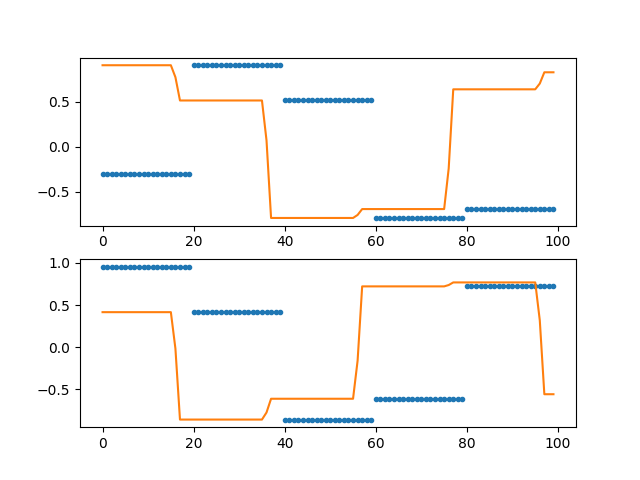

In [87]:
if 0: # Debug: visualize tx_samples_resampled
    pl.close("complex_interpolation")
    pl.figure("complex_interpolation", clear=True)

    i_s = len(tx_samples) - 1_000_000
    i_e = i_s + 100
    i_d = 1
    
    #pl.subplot(211)
    #pl.plot(np.angle(tx_samples[i_s:i_e:i_d]), '.')
    #pl.plot(np.angle(tx_samples_resampled[i_s:i_e:i_d]), '-')
    
    #pl.plot(np.abs(tx_samples[:i_end:i_skip]), '.')
    #pl.plot(np.abs(tx_samples_resampled[:i_end:i_skip]), '.')

    pl.subplot(211)
    pl.plot(np.real(tx_samples[i_s:i_e:i_d]), '.')
    pl.plot(np.real(tx_samples_resampled[i_s:i_e:i_d]), '-')
    
    pl.subplot(212)
    pl.plot(np.imag(tx_samples[i_s:i_e:i_d]), '.')
    pl.plot(np.imag(tx_samples_resampled[i_s:i_e:i_d]), '-')
    
    pl.show()

633102.9213117444


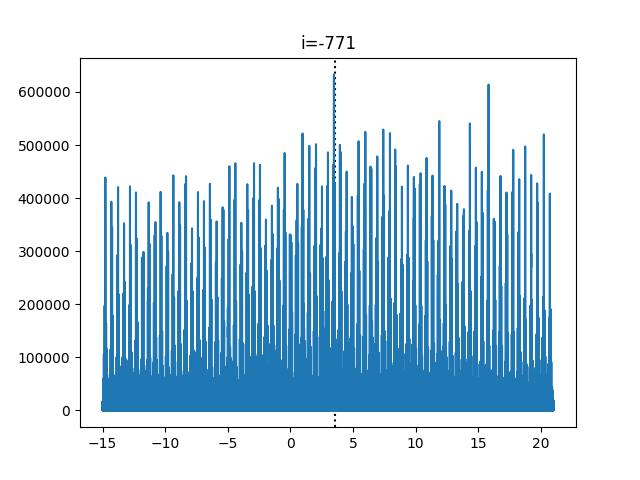

In [46]:
def touch(fname):
    try:
        os.utime(fname, None)
    except OSError:
        open(fname, 'a').close()

# Peak and minimized sidelobes at about -771. Fewer samples mean frequency is *up*

#for i in tqdm(range(-785, -760, 1)):
for i in [-771]:
    #filename = f"results/TEST/c_tx_resampled_{i:+d}.png"
    #filename = f"results/TEST/c_tx_resampled_2chan_{i:+d}.png"
    #
    #if os.path.exists(filename): continue
    #touch(filename)  # Reserve the filename to work on!
    
    tx_samples_resampled = scipy.signal.resample(tx_samples, len(tx_samples) + i)  # Around -200 other peaks start to dominate
    c = scipy.signal.correlate(rx_samples, tx_samples_resampled, mode='same')
    cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_resampled), mode='same') / sample_rate
    print(np.max(np.abs(c)))

    %matplotlib widget
    pl.close("c_tx_resampled")
    pl.figure("c_tx_resampled")
    pl.clf()
    pl.gca().axvline(1 + lt_tx_start, color="black", linestyle=":")
    pl.plot(cor_lags, np.abs(c))
    pl.title(f"{i=}")

    break
    #pl.savefig(filename)

In [ ]:
break

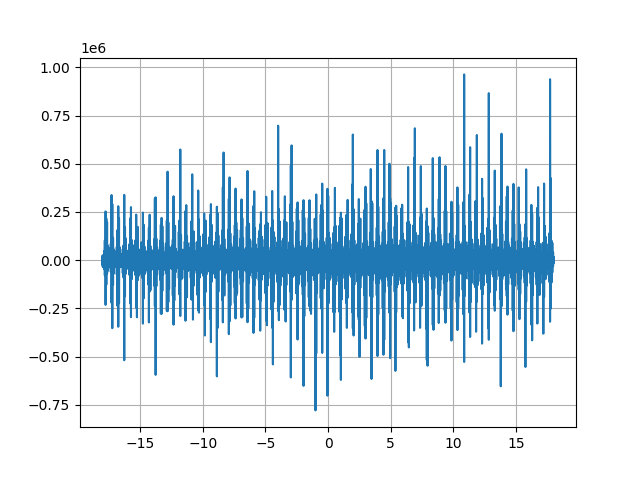

In [88]:
c = scipy.signal.correlate(rx_samples, tx_samples_resampled, mode='same')
pl.figure("c_rx_tx_resampled", clear=True)
cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_resampled), mode='same') / sample_rate
pl.plot(cor_lags, np.imag(c))
# If tx_samples_shifted and rx_samples are on the same timebase, we expect the correlation at 0.
#pl.gca().set_xlim(-1, 1)  
pl.grid()
pl.show()

In [ ]:
# Frequency shift the *RX* signal
lt_rx_start, dlt_rx_start = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_time, p_moon)
lt_rx_end, dlt_rx_end = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_end_time, p_moon)

doppler_start = -dlt_rx_start * frequency
doppler_end = -dlt_rx_end * frequency

print(f"{lt_rx_start=}")
print(f"{lt_rx_end=}")
print(f"{dlt_rx_start=}")
print(f"{dlt_rx_end=}")

print(f"{frequency * -dlt_rx_start=}")
print(f"{frequency * -dlt_rx_end=}")

print(f"{rx_duration * sample_rate * -dlt_rx_end=}")

# Compensate the rx_samples using a simple 'bulk' doppler correction model, linear
# from start to end. Generally good enough for a "look" of a few minutes.
# This means shifting the frequency by the doppler_start frequency plus the
# integral of the change in the doppler factor (doppler_rate) over the rx
# time interval.
doppler_rate = (doppler_end - doppler_start) / (rx_duration * au.s)
t_s = np.arange(len(rx_samples)) / sample_rate
phi_Hz = doppler_start + doppler_rate * t_s / 2
rx_samples_compensated = rx_samples * np.exp(-1j * 2 * np.pi * (phi_Hz * t_s).value).T

c = scipy.signal.correlate(rx_samples_compensated, tx_samples, mode='valid')
cor_lags = scipy.signal.correlation_lags(len(rx_samples_compensated), len(tx_samples), mode='valid') / sample_rate
print(c[len(c)//2])

pl.figure("c_rx_compensated_tx", clear=True)
cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_compensated), mode='valid') / sample_rate
pl.plot(cor_lags, c)
# If tx_samples{_compensated} and rx_samples{_compensated} both start at 0 time, we expect the correlation at 1 + lt_tx_start
pl.gca().set_xlim(1 + lt_rx_start - 0.01, 1 + lt_rx_start + 0.01)
pl.gca().axvline(1.0, color="black", linestyle=":")
pl.gca().axvline(1.0 + lt_rx_start, color="black", linestyle="--")
pl.gca().axvline(1.0 + lt_tx_start, color="black", linestyle=":")
pl.grid()
pl.show()

In [ ]:
# Frequency shift the *TX* signal
lt_tx_start, dlt_tx_start = moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_start_time, p_moon)
lt_tx_end, dlt_tx_end = moonPointLightTimeAndDeltaLightTime_spice_FWD(tx_end_time, p_moon)

doppler_start = -dlt_tx_start * frequency
doppler_end = -dlt_tx_end * frequency

# Compensate the tx_samples using a simple 'bulk' doppler correction model, linear
# from start to end. Generally good enough for a "look" of a few minutes.
# This means shifting the frequency by the doppler_start frequency plus the
# integral of the change in the doppler factor (doppler_rate) over the rx
# time interval.
doppler_rate = (doppler_end - doppler_start) / (tx_duration * au.s)
t_s = np.arange(len(tx_samples)) / sample_rate
phi_Hz = doppler_start + doppler_rate * t_s / 2
#tx_samples_compensated = tx_samples * np.exp(-1j * 2 * np.pi * (phi_Hz * t_s).value).T
tx_samples_compensated = tx_samples * np.exp(1j * 2 * np.pi * (phi_Hz * t_s).value).T  # NOTE: NEGATIVE COMPENSATION

c = scipy.signal.correlate(rx_samples, tx_samples_compensated, mode='valid')
print(c[len(c)//2])

pl.figure("c_rx_tx_compensated", clear=True)
cor_lags = scipy.signal.correlation_lags(len(rx_samples), len(tx_samples_compensated), mode='valid') / sample_rate
pl.plot(cor_lags, c)
# If tx_samples{_compensated} and rx_samples{_compensated} both start at 0 time, we expect the correlation at 1 + lt_tx_start
pl.gca().set_xlim(1 + lt_rx_start - 0.01, 1 + lt_rx_start + 0.01)
pl.gca().axvline(1.0, color="black", linestyle=":")
pl.gca().axvline(1.0 + lt_rx_start, color="black", linestyle="--")
pl.gca().axvline(1.0 + lt_tx_start, color="black", linestyle=":")
pl.grid()
pl.show()

In [ ]:
# HYPOTHESES for why rx and tx compensation aren't symmetrical:
# 1. My FWD SPICE function is (more) busted than the REV function. 

# HYPOTHESES FOR WHY THE ABSOLUTE CORRELATION PEAK DOESN'T OCCUR AT THE PREDICTED TIME
# 1. The SPICE functions are busted.
# 2. The Dwingeloo and/or Stockert clocks are busted.
# 3. Numerical issues plus noise are wreaking havok with the correlation.
# 4. PHASE ??? POLARITY ???

In [ ]:
#shift = 1045 # -1140.895
#tx0_sample_times = np.linspace(0, tx_duration, len(tx_samples), endpoint=False)
#tx_samples_shifted = tx_samples * np.exp(1j * 2 * np.pi * shift * tx0_sample_times).T
#c = scipy.signal.correlate(tx_samples_shifted, rx_samples, mode='same')
#print(c[len(c)//2])

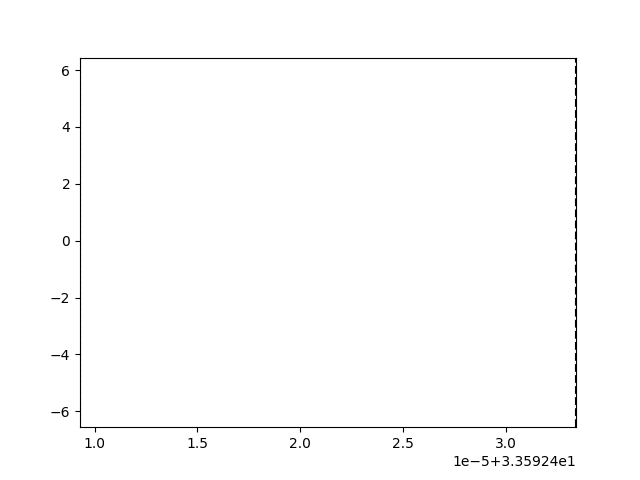

In [73]:
# Plots for time resampling method experiments
if 1:  # Check that the tx_shifted waveform fits in the expected time window.
    %matplotlib widget
    pl.figure("rx_tx_shifted_samples", clear=True)
    i_end = -1 # 1000000 # int(sample_rate.value * 5)
    i_skip = 100
    pl.plot(rx_sample_times0[:i_end:i_skip], rx_samples[:i_end:i_skip], '.')
    pl.plot(rx_sample_times0[:i_end:i_skip], tx_samples_resampled[:i_end:i_skip], '.')
    pl.gca().axvline(1.0, color="black", linestyle=":")
    pl.gca().axvline(1.0 + lt_tx_start, color="black", linestyle=":")
    pl.gca().axvline(1.0 + tx_duration + lt_tx_end, color="black", linestyle=":")
    pl.gca().axvline(1.0 + tx_duration + lt_tx_start, color="black", linestyle="--")
    pl.gca().set_xlim(1.0 + tx_duration + lt_tx_end, 1.0 + tx_duration + lt_tx_start)  
    pl.show()

if 0:
    %matplotlib widget
#    cor_lags = scipy.signal.correlation_lags(len(tx_samples_shifted), len(rx_samples), mode='same') / sample_rate
    pl.figure("rx_tx_correlate", clear=True)
    pl.plot(cor_lags, c)
    # If tx_samples and rx_samples{_compensated} both start at 0 time, we expect the correlation at 1 + lt_tx_start
    pl.gca().axvline(1.0, color="black", linestyle=":")
    pl.gca().axvline(1.0 + lt_tx_start, color="black", linestyle=":")
    # If tx_samples_shifted and rx_samples are on the same timebase, we expect the correlation at 0.
    #pl.gca().set_xlim(-1, 1)  
    pl.grid()
    pl.show()

In [ ]:
def moonLightTimeAndDeltaLightTime_spice_BCK(rx_astrotime):
    rx_time = csp.str2et(rx_astrotime.utc.value)
    # Find the sub-radar point: Compute the rectangular coordinates (in the target_frame)
    # of the sub rx observatory point, corrected for light time and stellar aberration.
    srp, t_ref, _ = csp.subpnt('INTERCEPT/ELLIPSOID', "MOON", rx_time, "MOON_ME", "CN", "STOCKERT")
    return moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_astrotime, srp)

if 1:
    delay, doppler_factor = moonLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime)
    print(f"{delay=}")
    print(f"{doppler_factor=}")
    print(f"{doppler_factor * frequency=}")

In [ ]:
def calculateDelayWindowIndices(sample_rate, delay_start, len_rx_samples, len_tx_samples):
    t_start = delay_start
    t_end = delay_start + MOON_RADIUS / ak.c * 2  # round-trip delay depth
    # HACK: PAD!
    t_start -= 0.01 * au.s
    t_end += 0.01 * au.s
    cor_lags = scipy.signal.correlation_lags(len_rx_samples, len_tx_samples, mode="valid") / sample_rate
    cor_i_start = np.argwhere(cor_lags > t_start)[0][0]
    cor_i_end = np.argwhere(cor_lags > t_end)[0][0]
    return cor_lags, cor_i_start, cor_i_end

In [ ]:
# CUDA implementation: about 50 it/s on an nvidia rtx 3080
def correlateSignalCUDA(tx_samples, rx_samples, cor_i_start, cor_i_end, f_shifts):
    tx_samples = cupy.asarray(tx_samples, dtype=cupy.complex64)
    rx_samples = cupy.asarray(rx_samples, dtype=cupy.complex64)
    A = cupy.asarray(np.zeros((len(f_shifts), cor_i_end - cor_i_start)))
    # Cache computations/allocations outside the for loop.
    fft_rx_samples = cupy.fft.fft(rx_samples)
    tx_samples_shifted = cupy.zeros_like(rx_samples)
    tx_range = 1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(tx_samples)) 
    for i in tqdm(range(len(f_shifts))):
        tx_samples_shifted[:len(tx_samples)] = tx_samples * cupy.exp(f_shifts[i] * tx_range)
        cor_shifted = cupy.fft.ifft(fft_rx_samples * cupy.conj(cupy.fft.fft(tx_samples_shifted)))
        A[i] = cupy.abs(cor_shifted[cor_i_start:cor_i_end])
    # Single copy back to CPU at the end.
    return cupy.asnumpy(A)

# Processing

In [ ]:
#DATA_PREFIX = f"{DATA_ROOT}/sdr-eme/rx-2025-03-11/"
DATA_PREFIX = f"{DATA_ROOT}/sdr-eme/rx-2025-06-21/"

# Scan the available files (Stockert RX only), collect the metadata
rx_info_map = {}
for filename in os.listdir(DATA_PREFIX):
    if not filename.startswith('stockert'): continue
    if '_1970_' in filename: continue  # Filter out weird datetime!
    if not filename.endswith('meta'): continue
    sigmf_file = sigmf.sigmffile.fromfile(DATA_PREFIX + filename, skip_checksum=True)
    rx_info_map[filename] = sigmf_file.get_global_info()

In [ ]:
# Span of files across the whole observation time window (want to see a lot of motion!)
SPECIAL_LIST = [
    #"stockert_eme_2025_06_21_08_48_35_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    #"stockert_eme_2025_06_21_09_06_52_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    #"stockert_eme_2025_06_21_09_46_51_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    #"stockert_eme_2025_06_21_10_01_49_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    #"stockert_eme_2025_06_21_10_45_50_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    #"stockert_eme_2025_06_21_10_26_29_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    #"stockert_eme_2025_06_21_11_27_05_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    #"stockert_eme_2025_06_21_11_18_31_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    #"stockert_eme_2025_06_21_11_24_12_1299.500MHz_0.25Msps_ci16_le.chan0.sigmf-meta",
    # chan1
    "stockert_eme_2025_06_21_08_48_35_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
#    "stockert_eme_2025_06_21_09_06_52_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
#    "stockert_eme_2025_06_21_09_46_51_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
#    "stockert_eme_2025_06_21_10_01_49_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
#    "stockert_eme_2025_06_21_10_45_50_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
#    "stockert_eme_2025_06_21_10_26_29_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
#    "stockert_eme_2025_06_21_11_27_05_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
#    "stockert_eme_2025_06_21_11_18_31_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
#    "stockert_eme_2025_06_21_11_24_12_1299.500MHz_0.25Msps_ci16_le.chan1.sigmf-meta",
]

In [ ]:
for rx_filename, rx_info in rx_info_map.items():
    #if not 'chan0' in rx_filename: continue
    #if not 'chan1' in rx_filename: continue
    desc = rx_info["core:description"]
    if 'cw-' in desc: continue  # Common
    if 'pulsed' in desc: continue  # Common
    #if not '30sec' in desc: continue
    #if not '60sec' in desc: continue
    if not (('60sec' in desc) or ('30sec' in desc)): continue   # For the 06_21 dataset 
    #if not '50000-' in desc: continue   # For the 03_11 dataset
    if not 'zadoff-chu' in desc: continue # Common
    #if not 'bpsk' in desc: continue

    if not (rx_filename in SPECIAL_LIST):
        continue

    print("Processing ", rx_filename)

    rx_samples, tx_samples, sample_rate, frequency, rx_start_astrotime = loadRxTxFiles(DATA_PREFIX + rx_filename)
    
    rx_duration = len(rx_samples) / sample_rate
    tx_duration = len(tx_samples) / sample_rate
    if rx_duration < 20 * au.s:
        print(f"SKIPPING DUE TO SHORT DURATION {rx_duration=} {tx_duration=}")
        continue
    
    # Compute the doppler/delay for the sub-radar point at the start and end of the rx window.
    delay_start, doppler_factor_start = moonLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime)
    rx_end_astrotime = rx_start_astrotime + rx_duration
    delay_end, doppler_factor_end = moonLightTimeAndDeltaLightTime_spice_BCK(rx_end_astrotime)
    doppler_start = -doppler_factor_start * frequency
    doppler_end = -doppler_factor_end * frequency

    # Compensate the rx_samples using a simple 'bulk' doppler correction model, linear
    # from start to end. Generally good enough for a "look" of a few minutes.
    # This means shifting the frequency by the doppler_start frequency plus the
    # integral of the change in the doppler factor (doppler_rate) over the rx
    # time interval.
    doppler_rate = (doppler_end - doppler_start) / rx_duration
    t_s = np.arange(len(rx_samples)) / sample_rate
    phi_Hz = doppler_start + doppler_rate * t_s / 2
    rx_samples_compensated = rx_samples * np.exp(-1j * 2 * np.pi * (phi_Hz * t_s).value).T
    
    # TODO: how many delay pixels wide could delay_start and delay_end be???
    min_delay = min(delay_start, delay_end) * au.s
    cor_lags, cor_i_start, cor_i_end = calculateDelayWindowIndices(sample_rate, TX_START + min_delay, len(rx_samples), len(tx_samples))

    # Calculate the range of doppler shifts by sampling around the terminator.
    rx_start_csptime = csp.str2et(rx_start_astrotime.utc.value)
    # Use Dwingeloo telescope as the light source, UMBRAL for the edge of any illumination!
    # To do so, we have to add the telescope radius (20m) to observatories.tf:
    #  BODY399999_RADII                    = (  0.02   0.02   0.02  )
    # And of course... I'm not sure that this is 100% legit, but testing seems to indicate it is.
    target_epoch, observer_pos, v_term = csp.edterm("UMBRAL", "DWINGELOO", "MOON", rx_start_csptime, "MOON_ME", "CN", "STOCKERT", 1000)  
    lt_term, dlt_term = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime, v_term)
    dlt_term *= -1

    # 3000 is roughly the delay depth / sample_rate, yielding a roughly square doppler/delay image.
    dlt_shifts = np.linspace(dlt_term.min(), dlt_term.max(), 3000)  
    f_shifts = dlt_shifts * frequency.value - doppler_start.value

    # Calculate the doppler/delay image
    A = correlateSignalCUDA(tx_samples, rx_samples_compensated, cor_i_start, cor_i_end, f_shifts)
#    # Cache 
#    os.makedirs(f"results/A", exist_ok=True)
#    np.save(open(f"results/A/{rx_filename}_A.npy", 'wb'), A)

#    # Load the doppler/delay image from cache
#    A = np.load(open(f"results/A/{rx_filename}_A.npy", 'rb'))
#    sample_rate = rx_info['core:sample_rate'] / au.s
#    rx_start_astrotime = at.Time(rx_info['dt:datetime'])
    
    log_A = np.log(A)
    # Debug output
    os.makedirs(f"results/TEST", exist_ok=True)
    pl.imsave(f"results/TEST/{rx_filename}_log_A.png", log_A.T, vmax=log_A.max() * 0.8, vmin=log_A.max() * 0.4) 

    break

    doppler_values = f_shifts * au.Hz + doppler_start
    delay_values = cor_lags[cor_i_start:cor_i_end]

    NSIDE = 500
    NPIX = hp.nside2npix(NSIDE)
    
    v = np.array(hp.pix2vec(NSIDE, np.arange(NPIX))).T
    
    # Roughly filter out the far hemisphere.
    v_near = v[:, 0] > 0
    v = v[v_near, :]

    # TODO: should we use rx_start_astrotime + TX_START?
    lt, dlt = moonPointLightTimeAndDeltaLightTime_spice_BCK(rx_start_astrotime, v)

    # HACK -- This additional lt delay seals the apparent 'rift' on the doppler equator.
    # But the rift is not symmetric?
    # And it's not consistent across rx files?
    # And it's huge compared to expected clock error!
    #lt += 0.00005  
    
    # Backstop values for searchsorted:
    doppler_values[-1] = 1000000.0 * au.Hz
    delay_values[-1] = 1000000.0 * au.s
    # TODO: Shouldn't actually have to do searches, since both doppler_values and delay_values have constant steps sizes!
    doppler_index = np.searchsorted(doppler_values, dlt * frequency)
    delay_index = np.searchsorted(delay_values, lt * au.s + TX_START)
    val_surface = np.zeros(NPIX, dtype=np.float32)
    val_surface[v_near] = log_A[doppler_index, delay_index]  # TODO: averaging?

    # Debug image with predicted doppler/delay points superimposed on the doppler/delay image.
    log_A[doppler_index, delay_index] = 10
    os.makedirs(f"results/TEST", exist_ok=True)
    pl.imsave(f"results/TEST/{rx_filename}_log_A_dd.png", log_A.T, vmax=log_A.max() * 0.8, vmin=log_A.max() * 0.4) 
    
    fig = pl.figure(figsize=(16,16))
    hp.orthview(val_surface,
                title='Moon Surface Value',
                flip='geo',  # Note: moon longitude is positive EAST
                fig=fig,
                half_sky=True,
                min=log_A.max() * 0.4,
                max=log_A.max() * 0.8,
               )
    hp.graticule()
    os.makedirs(f"results/TEST", exist_ok=True)
    pl.savefig(f"results/TEST/{rx_filename}.png")

In [ ]:
# Since the delay changes during the transmission, the signal length will stretch by the change in delay from the start to the end.
# This is one explanation for the doppler shift -- it's just a shift of timebase!
delay_stretch = (delay_end - delay_start) * au.s
#delay_stretch = -1.79877e-6 # "ppm" from Thomas' email
print(f"{delay_stretch=}")
print(delay_stretch / rx_duration)
print(delay_stretch / rx_duration * frequency)

# Compare this with the instantaneous doppler factors:
print(doppler_factor_start)
print(doppler_factor_start * frequency)
print(doppler_factor_end)
print(doppler_factor_end * frequency)

print((doppler_factor_start + doppler_factor_end) / 2.0 * frequency)

In [ ]:
if 1: # Search for best frequency/time shift using peak correlation strength, in a window around the expect return time.

    # Compute the doppler/delay for the sub-radar point at the start and end of the rx window.
    delay_start, dlt_start = moonDopplerFactorAndDelay_spice(rx_start_astrotime)
    rx_end_astrotime = rx_start_astrotime + rx_duration
    delay_end, dlt_end = moonDopplerFactorAndDelay_spice(rx_end_astrotime)
    f_shift_start = dlt_start * frequency
    f_shift_end = dlt_end * frequency
    print(f"{f_shift_start=}")
    print(f"{f_shift_end=}")
    # Simple 'bulk' doppler_rate model, linear from start to end. Generally good enough for a "look" of a few minutes.
    f_shift_rate = (f_shift_end - f_shift_start) / rx_duration
    print(f"{f_shift_rate=}")

    min_delay = min(delay_start, delay_end) * au.s
    print(f"{min_delay=}")
    cor_lags, cor_i_start, cor_i_end = calculateDelayWindowIndices(sample_rate, TX_START + min_delay, len(rx_samples), len(tx_samples))

    f_shifts = np.linspace(f_shift_start.to(au.Hz).value - 0.2, f_shift_start.to(au.Hz).value + 0.2, 100)
    
    # Do heavy compute in GPU memory
    cupy_tx_samples = cupy.asarray(tx_samples, dtype=cupy.complex64)
    cupy_rx_samples = cupy.asarray(rx_samples, dtype=cupy.complex64)
    # Cache computations/allocations outside the for loop.
    cupy_fft_rx_samples = cupy.fft.fft(cupy_rx_samples)
    #cupy_conj_fft_tx_samples = cupy.conj(cupy.fft.fft(cupy.pad(cupy_tx_samples, (0, len(rx_samples) - len(tx_samples)))))
    #cupy_rx_range = -1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(rx_samples))
    #cupy_rx_t_s = cupy.arange(len(rx_samples)) / sample_rate.value
    cupy_tx_samples_shifted = cupy.zeros_like(rx_samples)
    cupy_tx_range = 1j * 2 * cupy.pi / sample_rate.value * cupy.arange(len(tx_samples)) 
    
    best_peak_doppler = doppler_start
    best_peak_cor = 0.0
    for i in tqdm(range(len(f_shifts))):
        cupy_tx_samples_shifted[:len(tx_samples)] = cupy_tx_samples * cupy.exp(f_shifts[i] * cupy_tx_range)
        cupy_cor_shifted = cupy.fft.ifft(cupy_fft_rx_samples * cupy.conj(cupy.fft.fft(cupy_tx_samples_shifted)))
        cor_max = cupy.max(cupy.abs(cupy_cor_shifted[cor_i_start:cor_i_end]))
        if cor_max > best_peak_cor:
            best_peak_cor = cor_max
            best_peak_doppler = cupy_f_shifts[i]

    print(f"{best_peak_doppler=}")
    print(f"{best_peak_cor=}")
    print(f"Calculated vs search doppler delta: {doppler_start - best_peak_doppler * au.Hz}")

    doppler_start = best_peak_doppler * au.Hz

    if 1: # Debug
        phi_Hz = (-best_peak_doppler * cupy_rx_t_s) + (-doppler_rate.value * cupy_rx_t_s**2) / 2
        cupy_rx_samples_shifted = cupy_rx_samples * cupy.exp(-1j * 2 * np.pi * phi_Hz).T
        cupy_cor_shifted = cupy.fft.ifft(cupy.fft.fft(cupy_rx_samples_shifted) * cupy_conj_fft_tx_samples)
        pl.figure()
        pl.title("RX-compensated/TX correlation (delay window)")
        pl.plot(cor_lags[cor_i_start:cor_i_end], cupy.abs(cupy_cor_shifted[cor_i_start:cor_i_end]).get(), label="signal")
        #pl.gca().axvline(delay_start, linestyle="--", color="grey", label="expected based on Moon distance",)
        #pl.plot(cupy.abs(cupy_cor_shifted[cor_i_start:(cor_i_start+2000)]).get())
        #rx_samples_compensated = cupy_rx_samples_shifted.get()

In [ ]:
# Use ltime to find the precise TX time for each RX sample.

dwingeloo_id = csp.bodn2c("DWINGELOO")
stockert_id = csp.bodn2c("STOCKERT")
moon_id = csp.bodn2c("MOON")

dprint("dwingeloo_id")
dprint("stockert_id")
dprint("moon_id")

# Work backwards from the signal rx time at Stockert.
rx_time_stockert = csp.str2et(rx_start_astrotime.utc.value)
bounce_time_moon, elapsed_m_to_s = csp.ltime(rx_time_stockert, stockert_id, "<-", moon_id)
tx_time_dwingeloo, elapsed_d_to_m = csp.ltime(bounce_time_moon, moon_id, "<-", dwingeloo_id)

dprint("rx_start_astrotime")
dprint("rx_time_dwingeloo")
dprint("bounce_time_moon")
dprint("tx_time_stockert")

dprint("elapsed_d_to_m")
dprint("elapsed_m_to_s")
dprint("elapsed_d_to_m + elapsed_m_to_s")

delay_start, doppler_factor_start = moonLightTimeAndDeltaLightTime(rx_start_astrotime)
dprint("delay_start")

#p_moon, lt_m_to_s, dlt_m_to_s = csp.spkltc(moon_id, rx_time_stockert, "MOON_ME", "LT")
#for abcorr in ["NONE", "LT", "LT+S", "CN", "CN+S"]:
for abcorr in ["LT", "CN"]:
    p_moon, lt_m_to_s  = csp.spkezp(moon_id, rx_time_stockert, "ITRF93", abcorr, stockert_id)
    bounce_time_moon = rx_time_stockert - lt_m_to_s
    dprint("bounce_time_moon")
    #p_dwingeloo, lt_d_to_m  = csp.spkezp(dwingeloo_id, bounce_time_moon, "ITRF93", abcorr, moon_id)
    #print(f"{abcorr:8s} ", end='')
    #dprint("lt_m_to_s")
   # dprint("lt_d_to_m")
#p_tx_from_sr, lt_tx = csp.spkcpo_vector("STOCKERT", rx_time - lt_rx, ref_frame, "OBSERVER", ab_cor, p_moon_surf, "MOON", "MOON_ME")  # Bistatic: RX by Stockert
#v_sr_from_rx = csp.dvnorm_vector(surf_p_moon_from_rx)
#v_tx_from_sr = csp.dvnorm_vector(p_tx_from_sr)  # NOTE: Including the (1-dlt_r) factor from https://destevez.net/2025/04/analysis-of-the-camras-venus-radar-experiment/ makes only about 0.00025 Hz difference.
#c = csp.clight()



In [ ]:
ok, so

if I

havets